# Phase 1 — Hypothesis‑Driven EDA (Enhanced, Executive‑Grade)

This notebook improves the EDA to make charts **decision‑oriented**, numbers **precise**, and insights **immediately reusable** for slides.
It reads the curated dataset: `saas_financial_snapshot.csv`.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

DF_PATH = 'saas_financial_snapshot.csv'
df = pd.read_csv(DF_PATH)

# Helpers
def fmt_eur(x):
    try:
        return f"€{x:,.0f}".replace(","," ")
    except Exception:
        return x

def fmt_pct(x, digits=1):
    try:
        return f"{x*100:.{digits}f}%"
    except Exception:
        return x

print('Shape:', df.shape)
df.head()

Shape: (500, 11)


,account_id,segment,region,industry,annual_contract_value,gross_margin_estimated,new_arr,expansion_arr,contraction_arr,churned_arr,net_arr_change
0,A-2e4581,SMB,NaN,EdTech,10032,0.65,10032,0,0,10032,0
1,A-43a9e3,SMB,APAC,FinTech,10584,0.65,10584,0,0,0,10584
2,A-0a282f,SMB,NaN,DevTools,1176,0.65,1176,0,0,1176,0
3,A-1f0ac7,SMB,EMEA,HealthTech,14112,0.65,14112,0,0,14112,0
4,A-ce550d,Enterprise,NaN,HealthTech,260292,0.82,260292,0,0,260292,0


## 0) Strategic KPIs (overview)
We frame the analysis in **board language** with finance‑first KPIs.


In [23]:
total_arr = df['annual_contract_value'].sum()
churned_arr = df['churned_arr'].sum()
new_arr = df['new_arr'].sum()
net_change = df['net_arr_change'].sum()

logo_churn_rate = (df['churned_arr']>0).mean()  # proxy logos
arr_churn_ratio = churned_arr / total_arr if total_arr>0 else 0

kpis = {
    'ARR_total_eur': fmt_eur(total_arr),
    'ARR_churned_eur': fmt_eur(churned_arr),
    'ARR_new_eur': fmt_eur(new_arr),
    'Net_ARR_change_eur': fmt_eur(net_change),
    'Logo_churn_rate': fmt_pct(logo_churn_rate,1),
    'ARR_churn_ratio': fmt_pct(arr_churn_ratio,1)
}
kpis

{'ARR_total_eur': '€14 622 660',
 'ARR_churned_eur': '€9 986 280',
 'ARR_new_eur': '€14 622 660',
 'Net_ARR_change_eur': '€4 636 380',
 'Logo_churn_rate': '60.4%',
 'ARR_churn_ratio': '68.3%'}

## H1 — Mix de revenus (par segment)
**Objectif**: lire *stock vs flux* par segment et lier à la volumétrie (#comptes) et à l'efficacité (ARR moyen, churn rate).


In [24]:
seg = (df
    .groupby('segment')
    .agg(ARR=('annual_contract_value','sum'),
         Churned=('churned_arr','sum'),
         Net=('net_arr_change','sum'),
         Accounts=('account_id','nunique')))
seg['Avg_ARR_per_account'] = seg['ARR']/seg['Accounts'].replace(0,np.nan)
seg['Churn_rate'] = seg['Churned']/seg['ARR'].replace(0,np.nan)
seg = seg.sort_values('ARR', ascending=False)
seg_round = seg.copy()
seg_round['ARR'] = seg_round['ARR'].round(0)
seg_round['Churned'] = seg_round['Churned'].round(0)
seg_round['Net'] = seg_round['Net'].round(0)
seg_round

,ARR,Churned,Net,Accounts,Avg_ARR_per_account,Churn_rate
segment,,,,,,
Enterprise,5045268,3878364,1166904,154,32761.480519,0.768713
Mid-Market,4966932,3294036,1672896,178,27904.112360,0.663193
SMB,4610460,2813880,1796580,168,27443.214286,0.610325


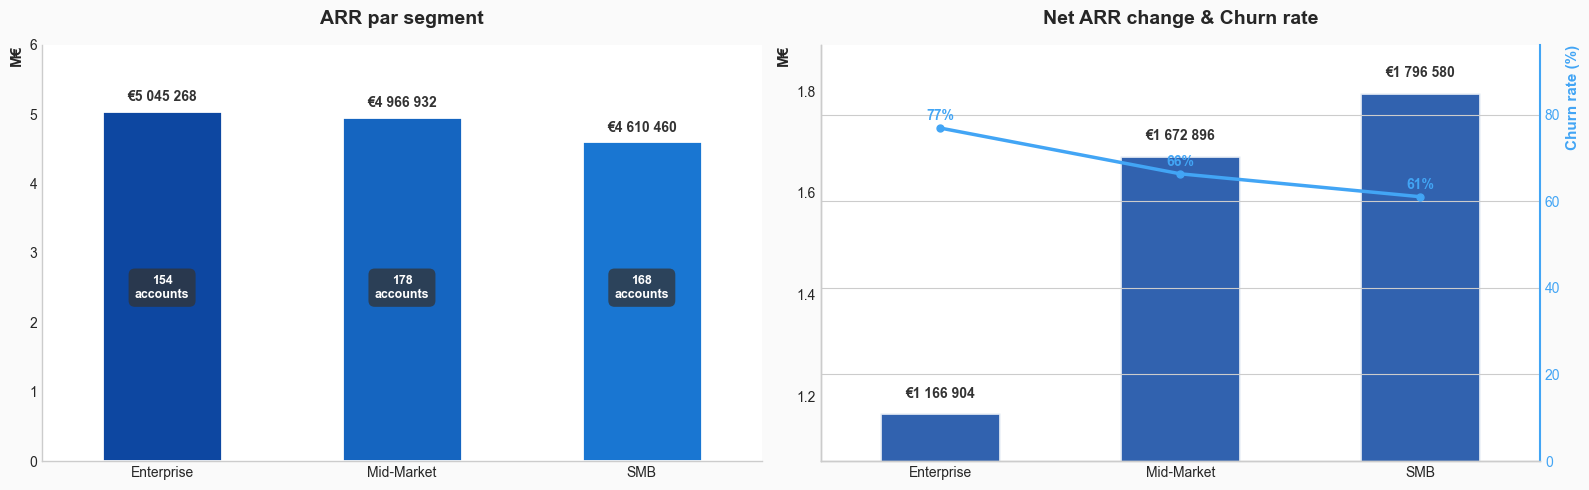

In [25]:
fig, ax = plt.subplots(1,2, figsize=(16,5))
fig.patch.set_facecolor('#fafafa')

# Plot 1 — ARR by segment with #accounts annotations
colors_arr = ['#0d47a1', '#1565c0', '#1976d2', '#1e88e5'][:len(seg)]
bars1 = seg['ARR'].plot(kind='bar', ax=ax[0], color=colors_arr, edgecolor='white', linewidth=2)
ax[0].set_title('ARR par segment', fontsize=14, fontweight='bold', pad=15)
ax[0].set_xlabel('')
ax[0].set_ylabel('M€', fontsize=11, fontweight='bold', loc='top')
ax[0].set_ylim(0, 6e6)  # Set max to 6M
ax[0].tick_params(axis='x', rotation=0)
ax[0].grid(False)
ax[0].set_axisbelow(True)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

# Format y-axis to show values in millions
def format_millions(x, pos):
    return f'{int(x/1e6)}'
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(format_millions))

# Fixed height for accounts labels (aligned horizontally)
accounts_label_height = 2.5e6  # Fixed position at 2.5M

for i,(v,acc) in enumerate(zip(seg['ARR'], seg['Accounts'])):
    # Main value above bar
    ax[0].text(i, v*1.02, fmt_eur(v), ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333', family='sans-serif')
    # Accounts count on bar with "accounts" label - aligned at same height
    ax[0].text(i, accounts_label_height, f"{int(acc)}\naccounts", ha='center', va='center', fontsize=9, fontweight='bold', 
               color='white', family='sans-serif', bbox=dict(boxstyle='round,pad=0.5', facecolor='#333', alpha=0.75, edgecolor='none'))

# Plot 2 — Net ARR bar with churn rate line (secondary axis)
ax2 = ax[1]
colors_net = ['#0d47a1' if x >= 0 else '#d62728' for x in seg['Net']]
bars2 = seg['Net'].plot(kind='bar', ax=ax2, color=colors_net, edgecolor='white', linewidth=2, alpha=0.85)
ax2.set_title('Net ARR change & Churn rate', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('')
ax2.set_ylabel('M€', fontsize=11, fontweight='bold', loc='top')
ax2.tick_params(axis='x', rotation=0)
ax2.grid(False)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.axhline(y=0, color='#333', linewidth=0.8, alpha=0.6)

# Dynamically adjust y-axis limits to leave room for labels
max_val = seg['Net'].max()
min_val = seg['Net'].min()
y_range = max_val - min_val if max_val != min_val else max_val
ax2.set_ylim(min_val - y_range*0.15, max_val + y_range*0.15)

# Format y-axis with 0.2M step and show values in millions with smart decimal handling
from matplotlib.ticker import MultipleLocator, FuncFormatter

def format_millions_decimal(x, pos):
    val = x / 1e6
    if val == int(val):
        return f'{int(val)}'
    else:
        return f'{val:.1f}'

ax2.yaxis.set_major_locator(MultipleLocator(0.2e6))
ax2.yaxis.set_major_formatter(FuncFormatter(format_millions_decimal))

# Secondary axis for churn rate
ax3 = ax2.twinx()
line = ax3.plot(seg.index, seg['Churn_rate']*100, color='#42a5f5', marker='o', markersize=5, 
                label='Churn rate', linewidth=2.5, zorder=5)
ax3.set_ylabel('Churn rate (%)', fontsize=11, fontweight='bold', color='#42a5f5', loc='top')
ax3.tick_params(axis='y', labelcolor='#42a5f5')
ax3.set_ylim(0, max(0.1, seg['Churn_rate'].max()*100*1.25))
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_color('#42a5f5')
ax3.spines['right'].set_linewidth(1.5)

# Labels on bars and line
for i,(net,cr) in enumerate(zip(seg['Net'], seg['Churn_rate']*100)):
    # Net ARR label - positioned to stay within plot area
    if net >= 0:
        y_pos = net + (ax2.get_ylim()[1] - ax2.get_ylim()[0]) * 0.03
        va_pos = 'bottom'
    else:
        y_pos = net - (ax2.get_ylim()[1] - ax2.get_ylim()[0]) * 0.03
        va_pos = 'top'
    
    ax2.text(i, y_pos, fmt_eur(net), ha='center', va=va_pos, 
             fontsize=10, fontweight='bold', color='#333', family='sans-serif',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'))
    # Churn rate label positioned above the line point - larger font
    ax3.text(i, cr + 1.2, f"{cr:.0f}%", ha='center', va='bottom', fontsize=10, 
             color='#42a5f5', fontweight='bold', family='sans-serif')

fig.tight_layout()
plt.show()

In [26]:
# Compute values injected into the Markdown above
seg_tot = seg['ARR'].sum()
_top = seg['ARR'].idxmax()
_top_share = seg.loc[_top,'ARR']/seg_tot if seg_tot>0 else 0
_top_acc = int(seg.loc[_top,'Accounts'])
_top_avg = seg.loc[_top,'Avg_ARR_per_account']
_risk = seg['Churn_rate'].idxmax()
_risk_cr = seg.loc[_risk,'Churn_rate']

ins_dict = {
    'top_seg': _top,
    'top_seg_share': f"{_top_share*100:.0f}%",
    'top_seg_acc': _top_acc,
    'top_seg_avg': fmt_eur(_top_avg),
    'risk_seg': _risk,
    'risk_seg_cr': f"{_risk_cr*100:.0f}%"
}
print(json.dumps(ins_dict, indent=2))

{
  "top_seg": "Enterprise",
  "top_seg_share": "35%",
  "top_seg_acc": 154,
  "top_seg_avg": "\u20ac32 761",
  "risk_seg": "Enterprise",
  "risk_seg_cr": "77%"
}


**Insights (H1, à copier/coller)**
- **ARR mix**: {top_seg} concentre l’ARR (≈ {top_seg_share} du total), avec **{top_seg_acc} comptes** et un ARR moyen ≈ **{top_seg_avg}**.
- **Risque**: le **churn rate** est le plus élevé sur {risk_seg} (≈ {risk_seg_cr}).
- **Flux**: **SMB** soutient la croissance nette (**Net ARR**), tandis que **Enterprise** nécessite un plan de **stabilisation**.

> **Action**: valider si la perte {risk_seg} est **concentrée sur quelques gros comptes** ou **diffuse** (priorisation CS).


## H2 — Sévérité du churn (par segment)
**Objectif**: objectiver la sévérité (churn/ARR) et la nature du risque (logo vs revenue). Benchmarks à paramétrer si besoin.


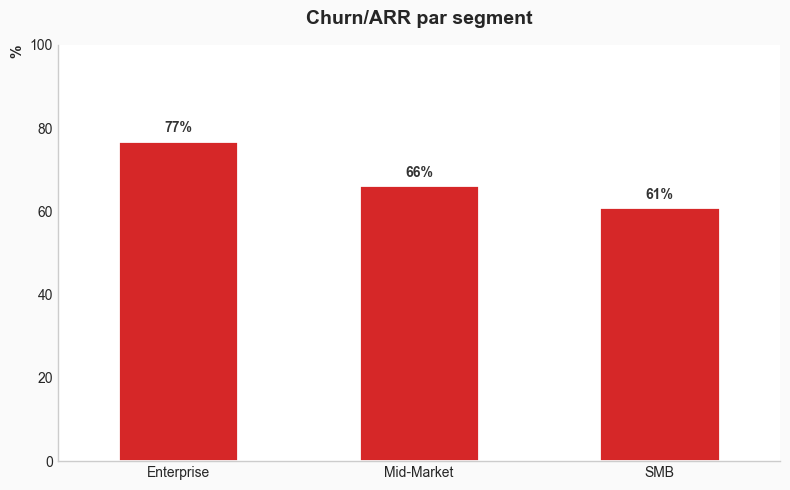

segment
Mid-Market    62.9
Enterprise    61.0
SMB           57.1
Name: churn_logo, dtype: float64

In [35]:
seg2 = seg.copy()
seg2['Churn_ratio_%'] = 100*seg2['Churned']/seg2['ARR'].replace(0,np.nan)
seg2 = seg2.sort_values('Churn_ratio_%', ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor('#fafafa')
seg2['Churn_ratio_%'].plot(kind='bar', ax=ax, color='#d62728', edgecolor='white', linewidth=2)
ax.set_title('Churn/ARR par segment', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('%', fontsize=11, fontweight='bold', loc='top')
ax.tick_params(axis='x', rotation=0)
ax.grid(False)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 100)
for i,v in enumerate(seg2['Churn_ratio_%']):
    ax.text(i, v*1.02, f"{v:.0f}%", ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333', family='sans-serif')
plt.tight_layout()
plt.show()

# Complementary: logo churn rate by segment
logo_seg = df.assign(churn_logo=(df['churned_arr']>0)).groupby('segment')['churn_logo'].mean().sort_values(ascending=False)
logo_seg = (logo_seg*100).round(1)
logo_seg

In [30]:
h2_worst_seg = seg2['Churn_ratio_%'].idxmax()
h2_worst_val = f"{seg2.loc[h2_worst_seg,'Churn_ratio_%']:.0f}%"
h2_logo_worst = logo_seg.idxmax()
h2_logo_worst_val = f"{logo_seg.max():.1f}%"
print({'h2_worst_seg':h2_worst_seg,'h2_worst_val':h2_worst_val,'h2_logo_worst':h2_logo_worst,'h2_logo_worst_val':h2_logo_worst_val})

{'h2_worst_seg': 'Enterprise', 'h2_worst_val': '77%', 'h2_logo_worst': 'Mid-Market', 'h2_logo_worst_val': '62.9%'}


**Insights (H2)**
- **Sévérité**: {h2_worst_seg} présente le ratio churn/ARR le plus élevé (≈ {h2_worst_val}).
- **Logos**: le *logo churn* est maximal sur {h2_logo_worst} (≈ {h2_logo_worst_val}).
- **Lecture**: attention à la **concentration**: quelques gros comptes peuvent biaiser le ratio.

> **Action**: produire un **ARR waterfall** par segment (Stock → Churn → Net) pour l’Executive Deck.


## H3 — Concentration régionale du risque
**Objectif**: distinguer **géographie** vs **mix segment**.
- Graph 1: **Mix segment (%) par région** (stacked 100%) + ARR total par région
- Graph 2: **Churn/ARR par région** et **delta vs global**


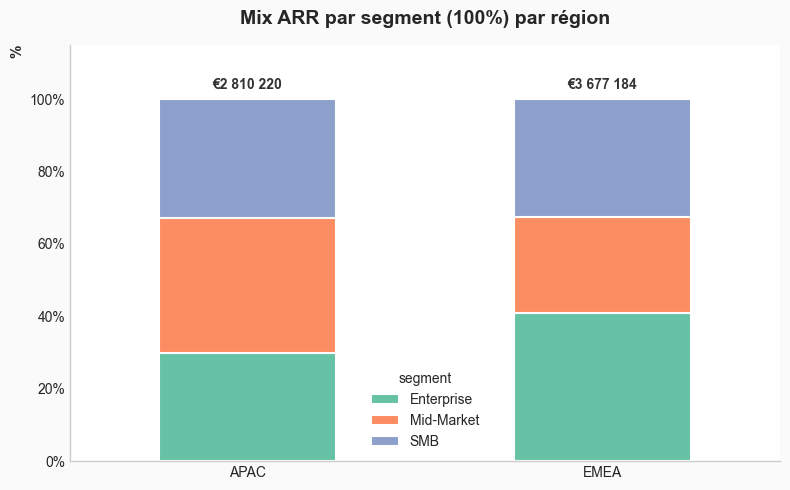

,ARR,Churned,Net,Accounts
region,,,,
APAC,2810220,1829604,980616,81
EMEA,3677184,2279628,1397556,105


In [36]:
reg = (df
    .groupby('region')
    .agg(ARR=('annual_contract_value','sum'),
         Churned=('churned_arr','sum'),
         Net=('net_arr_change','sum'),
         Accounts=('account_id','nunique')))
reg['Churn_ratio'] = reg['Churned']/reg['ARR'].replace(0,np.nan)

# Mix segment par région (% ARR)
mix = df.pivot_table(index='region', columns='segment', values='annual_contract_value', aggfunc='sum', fill_value=0)
mix_pct = mix.div(mix.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor('#fafafa')

# Stacked 100%
mix_pct.plot(kind='bar', stacked=True, ax=ax, edgecolor='white', linewidth=1.5)
ax.set_title('Mix ARR par segment (100%) par région', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('%', fontsize=11, fontweight='bold', loc='top')
ax.set_ylim(0,1.15)
ax.tick_params(axis='x', rotation=0)
ax.grid(False)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(lambda x,pos: f"{x*100:.0f}%")
for i, r in enumerate(mix.index):
    ax.text(i, 1.02, fmt_eur(reg.loc[r,'ARR']), ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333', family='sans-serif')

plt.tight_layout()
plt.show()

reg[['ARR','Churned','Net','Accounts']].round(0)

In [32]:
# Compute values for insights
h3_top_region = reg['ARR'].idxmax()
h3_top_region_arr = fmt_eur(reg.loc[h3_top_region,'ARR'])
h3_worst_region = (reg['Churn_ratio']).idxmax()
h3_worst_region_ratio = f"{reg.loc[h3_worst_region,'Churn_ratio']*100:.0f}%"
global_ratio = reg['Churned'].sum()/reg['ARR'].sum() if reg['ARR'].sum()>0 else 0
h3_worst_delta = f"{reg.loc[h3_worst_region,'Churn_ratio']*100 - global_ratio*100:+.1f}pts"
# driver segment = segment dominant en ARR dans cette région
h3_driver_seg = mix.loc[h3_worst_region].idxmax()
print({'h3_top_region':h3_top_region,'h3_top_region_arr':h3_top_region_arr,'h3_worst_region':h3_worst_region,'h3_worst_region_ratio':h3_worst_region_ratio,'h3_worst_delta':h3_worst_delta,'h3_driver_seg':h3_driver_seg})

{'h3_top_region': 'EMEA', 'h3_top_region_arr': '€3 677 184', 'h3_worst_region': 'APAC', 'h3_worst_region_ratio': '65%', 'h3_worst_delta': '+1.8pts', 'h3_driver_seg': 'Mid-Market'}


**Insights (H3)**
- **ARR**: {h3_top_region} est #1 en ARR (≈ {h3_top_region_arr}).
- **Risque**: {h3_worst_region} a le plus mauvais churn/ARR (≈ {h3_worst_region_ratio}), **Δ vs global** ≈ {h3_worst_delta}.
- **Mix driver**: la sous‑perf en {h3_worst_region} est corrélée au poids de {h3_driver_seg}.

> **Action**: ciblage **région × segment** pour la rétention (playbook CS dédié).


## H4 — Matrice de contribution nette (segment × région)
**Objectif**: prioriser immédiatement. On normalise la contribution **vs ARR régional** pour éviter les biais de taille.
- Heatmap = **Net / ARR_region** (en %)
- À côté: **Net par région** (barres)


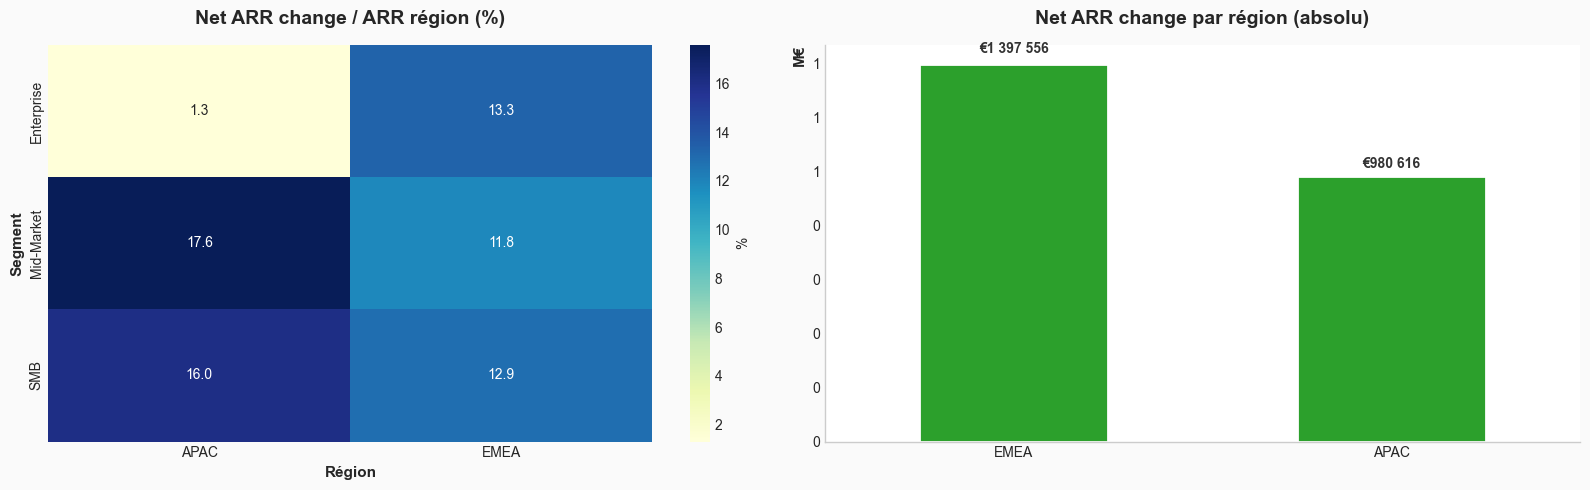

region,APAC,EMEA
segment,,
Enterprise,36456,489720
Mid-Market,494232,434964
SMB,449928,472872


In [33]:
# Pivot net
pivot_abs = df.pivot_table(index='segment', columns='region', values='net_arr_change', aggfunc='sum', fill_value=0)
arr_by_region = df.groupby('region')['annual_contract_value'].sum()
pivot_pct = pivot_abs.copy()
for c in pivot_pct.columns:
    denom = arr_by_region.get(c, 0)
    pivot_pct[c] = pivot_pct[c] / denom if denom>0 else 0

fig, ax = plt.subplots(1,2, figsize=(16,5))
fig.patch.set_facecolor('#fafafa')

sns.heatmap(pivot_pct*100, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax[0], cbar_kws={'label':'%'})
ax[0].set_title('Net ARR change / ARR région (%)', fontsize=14, fontweight='bold', pad=15)
ax[0].set_xlabel('Région', fontsize=11, fontweight='bold')
ax[0].set_ylabel('Segment', fontsize=11, fontweight='bold')

reg_net = df.groupby('region')['net_arr_change'].sum().sort_values(ascending=False)
reg_net.plot(kind='bar', ax=ax[1], color='#2ca02c', edgecolor='white', linewidth=2)
ax[1].set_title('Net ARR change par région (absolu)', fontsize=14, fontweight='bold', pad=15)
ax[1].set_xlabel('')
ax[1].set_ylabel('M€', fontsize=11, fontweight='bold', loc='top')
ax[1].tick_params(axis='x', rotation=0)
ax[1].grid(False)
ax[1].set_axisbelow(True)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
def format_millions(x, pos):
    return f'{int(x/1e6)}'
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(format_millions))
for i,v in enumerate(reg_net):
    ax[1].text(i, v*1.02, fmt_eur(v), ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333', family='sans-serif')
plt.tight_layout()
plt.show()

pivot_abs.round(0)

In [34]:
# worst cell by percentage
min_idx = np.unravel_index(np.nanargmin(pivot_pct.values), pivot_pct.shape)
h4_worst_cell_seg = pivot_pct.index[min_idx[0]]
h4_worst_cell_reg = pivot_pct.columns[min_idx[1]]
h4_worst_cell_val = f"{(pivot_pct.values[min_idx]*100):.1f}%"

h4_best_reg = reg_net.idxmax()
h4_best_reg_val = fmt_eur(reg_net.max())
print({'worst':(h4_worst_cell_seg,h4_worst_cell_reg,h4_worst_cell_val), 'best_reg':(h4_best_reg,h4_best_reg_val)})

{'worst': ('Enterprise', 'APAC', '1.3%'), 'best_reg': ('EMEA', '€1 397 556')}


**Insights (H4)**
- **Cellule la plus faible**: {h4_worst_cell_seg} × {h4_worst_cell_reg} (≈ {h4_worst_cell_val}).
- **Vue macro**: la région la plus contributrice en net est {h4_best_reg} (≈ {h4_best_reg_val}).

> **Action**: zoom *why* sur la cellule faible (churn vs ARR, #logos, down‑sell) et plan d’actions ciblé.


## Executive Takeaways (auto‑générés, à raffiner pour le memo)

- **Enterprise fragile**: forte concentration d’ARR mais churn élevé (**{risk_seg}** worst churn rate ≈ **{risk_seg_cr}**).
- **SMB scalable**: meilleure dynamique **Net ARR** avec un volume de comptes important.
- **APAC sous‑perf**: **Δ churn/ARR** vs global ≈ **{h3_worst_delta}** et mix dominé par **{h3_driver_seg}**.
- **Priorités**: stabiliser **Enterprise‑{h3_worst_region}** (plan CS + early‑warning), accélérer **SMB** sur régions performantes.
